a)

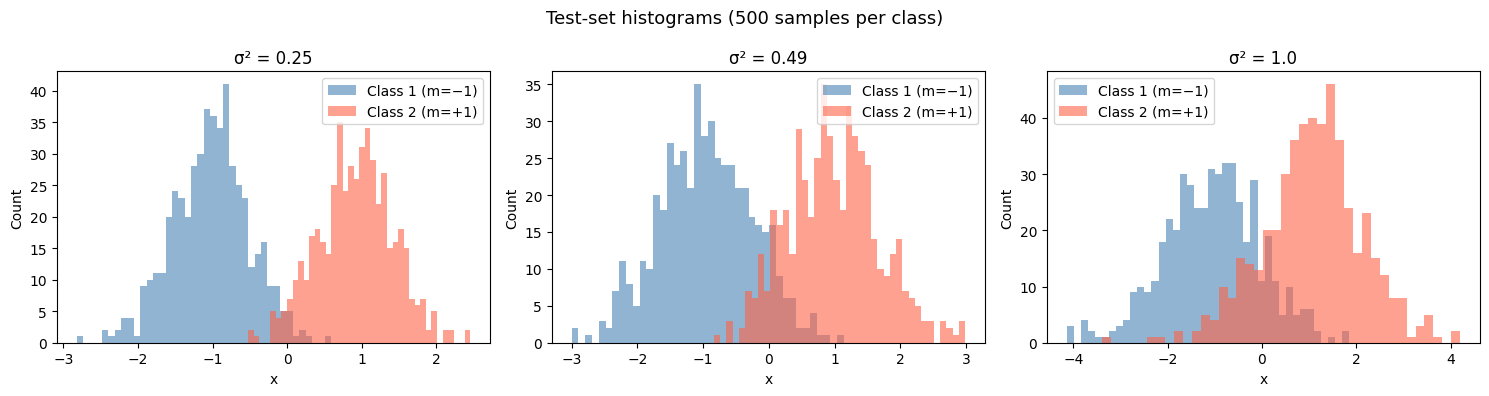


Bayes error rates (theoretical lower bound):
  σ² = 0.25  →  P_e ≈ 0.0228  (2.28%)
  σ² = 0.49  →  P_e ≈ 0.0766  (7.66%)
  σ² = 1.00  →  P_e ≈ 0.1587  (15.87%)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

dataset_info = [
    ("datasets/dataset_1_sigma2_025.npy", 0.25),
    ("datasets/dataset_2_sigma2_049.npy", 0.49),
    ("datasets/dataset_3_sigma2_10.npy",  1.00),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (path, sigma2) in zip(axes, dataset_info):
    data = np.load(path)
    # First 500 of each class are train, last 500 are test
    test = np.concatenate([data[500:1000], data[1500:]])

    c1 = test[test[:, 1] == 0, 0]
    c2 = test[test[:, 1] == 1, 0]

    ax.hist(c1, bins=40, alpha=0.6, color="steelblue", label="Class 1 (m=−1)")
    ax.hist(c2, bins=40, alpha=0.6, color="tomato",    label="Class 2 (m=+1)")
    ax.set_title(f"σ² = {sigma2}")
    ax.set_xlabel("x")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Test-set histograms (500 samples per class)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Bayes (optimal) error rate for each dataset ──────────────────────────────
# For two equal-prior Gaussians with equal variance the Bayes error is:
#   P_e = Q( |m2-m1| / (2σ) )  where Q is the complementary CDF of N(0,1)
from scipy.special import erfc

print("\nBayes error rates (theoretical lower bound):")
for _, sigma2 in dataset_info:
    sigma = np.sqrt(sigma2)
    d = abs(1 - (-1))          # |m2 - m1| = 2
    pe = 0.5 * erfc(d / (2 * sigma * np.sqrt(2)))
    print(f"  σ² = {sigma2:.2f}  →  P_e ≈ {pe:.4f}  ({pe*100:.2f}%)")

b)

True (Bayes) error rates — known class densities
    σ²       σ    d/(2σ)         P_e     P_e (%)
------------------------------------------------
  0.25  0.5000    2.0000    0.022750     2.2750%
  0.49  0.7000    1.4286    0.076564     7.6564%
  1.00  1.0000    1.0000    0.158655    15.8655%

Formula: P_e = Q(|m2−m1| / 2σ) = ½·erfc(|m2−m1| / 2σ√2)
  with m1 = -1.0, m2 = 1.0, decision boundary x* = 0



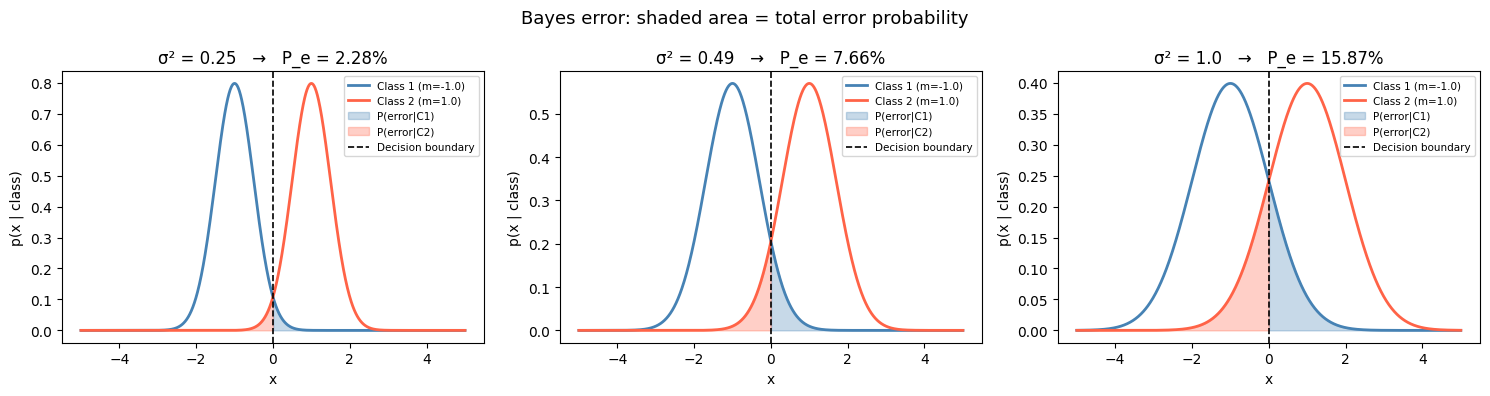

In [ ]:
import numpy as np
from scipy.special import erfc
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
m1, m2 = -1.0, 1.0          # class means
variances = [0.25, 0.49, 1.00]

print("True (Bayes) error rates — known class densities")
print("=" * 48)
print(f"{'σ²':>6}  {'σ':>6}  {'d/(2σ)':>8}  {'P_e':>10}  {'P_e (%)':>10}")
print("-" * 48)

results = []
for sigma2 in variances:
    sigma = np.sqrt(sigma2)
    snr   = abs(m2 - m1) / (2 * sigma)          # = 1/σ  (since |m2-m1|=2)
    pe    = 0.5 * erfc(snr / np.sqrt(2))
    results.append((sigma2, sigma, snr, pe))
    print(f"{sigma2:>6.2f}  {sigma:>6.4f}  {snr:>8.4f}  {pe:>10.6f}  {pe*100:>9.4f}%")

print("=" * 48)
print("\nFormula: P_e = Q(|m2−m1| / 2σ) = ½·erfc(|m2−m1| / 2σ√2)")
print(f"  with m1 = {m1}, m2 = {m2}, decision boundary x* = 0\n")

# ── Visualise the Bayes error geometrically ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.linspace(-5, 5, 1000)

for ax, (sigma2, sigma, snr, pe) in zip(axes, results):
    from scipy.stats import norm
    p1 = norm.pdf(x, m1, sigma)
    p2 = norm.pdf(x, m2, sigma)

    ax.plot(x, p1, color="steelblue", lw=2, label=f"Class 1 (m={m1})")
    ax.plot(x, p2, color="tomato",    lw=2, label=f"Class 2 (m={m2})")

    # Shade error regions
    ax.fill_between(x, p1, where=(x >= 0), color="steelblue", alpha=0.3, label=f"P(error|C1)")
    ax.fill_between(x, p2, where=(x <= 0), color="tomato",    alpha=0.3, label=f"P(error|C2)")
    ax.axvline(0, color="black", lw=1.2, linestyle="--", label="Decision boundary")

    ax.set_title(f"σ² = {sigma2}   →   P_e = {pe*100:.2f}%")
    ax.set_xlabel("x")
    ax.set_ylabel("p(x | class)")
    ax.legend(fontsize=7.5)

plt.suptitle("Bayes error: shaded area = total error probability", fontsize=13)
plt.tight_layout()
plt.show()

c)

Dataset 2  (σ² = 0.49,  Bayes error = 7.66%)

── NT = 5 per class (10 total) ──────────────────────────────
  Repeat 1:  CM = [[  5   0]   error =   0.0%
              [  0   5]]
  Repeat 2:  CM = [[  4   1]   error =  20.0%
              [  1   4]]
  Repeat 3:  CM = [[  5   0]   error =   0.0%
              [  0   5]]
  Repeat 4:  CM = [[  5   0]   error =  20.0%
              [  2   3]]
  Repeat 5:  CM = [[  5   0]   error =   0.0%
              [  0   5]]

  Averaged CM (over 5 repeats):
    [[  4.80    0.20]
     [  0.60    4.40]]
  Averaged error rate : 8.00%

── NT = 20 per class (40 total) ──────────────────────────────
  Repeat 1:  CM = [[ 19   1]   error =  10.0%
              [  3  17]]
  Repeat 2:  CM = [[ 16   4]   error =  12.5%
              [  1  19]]
  Repeat 3:  CM = [[ 20   0]   error =   0.0%
              [  0  20]]
  Repeat 4:  CM = [[ 20   0]   error =   5.0%
              [  2  18]]
  Repeat 5:  CM = [[ 18   2]   error =  10.0%
              [  2  18]]

  Average

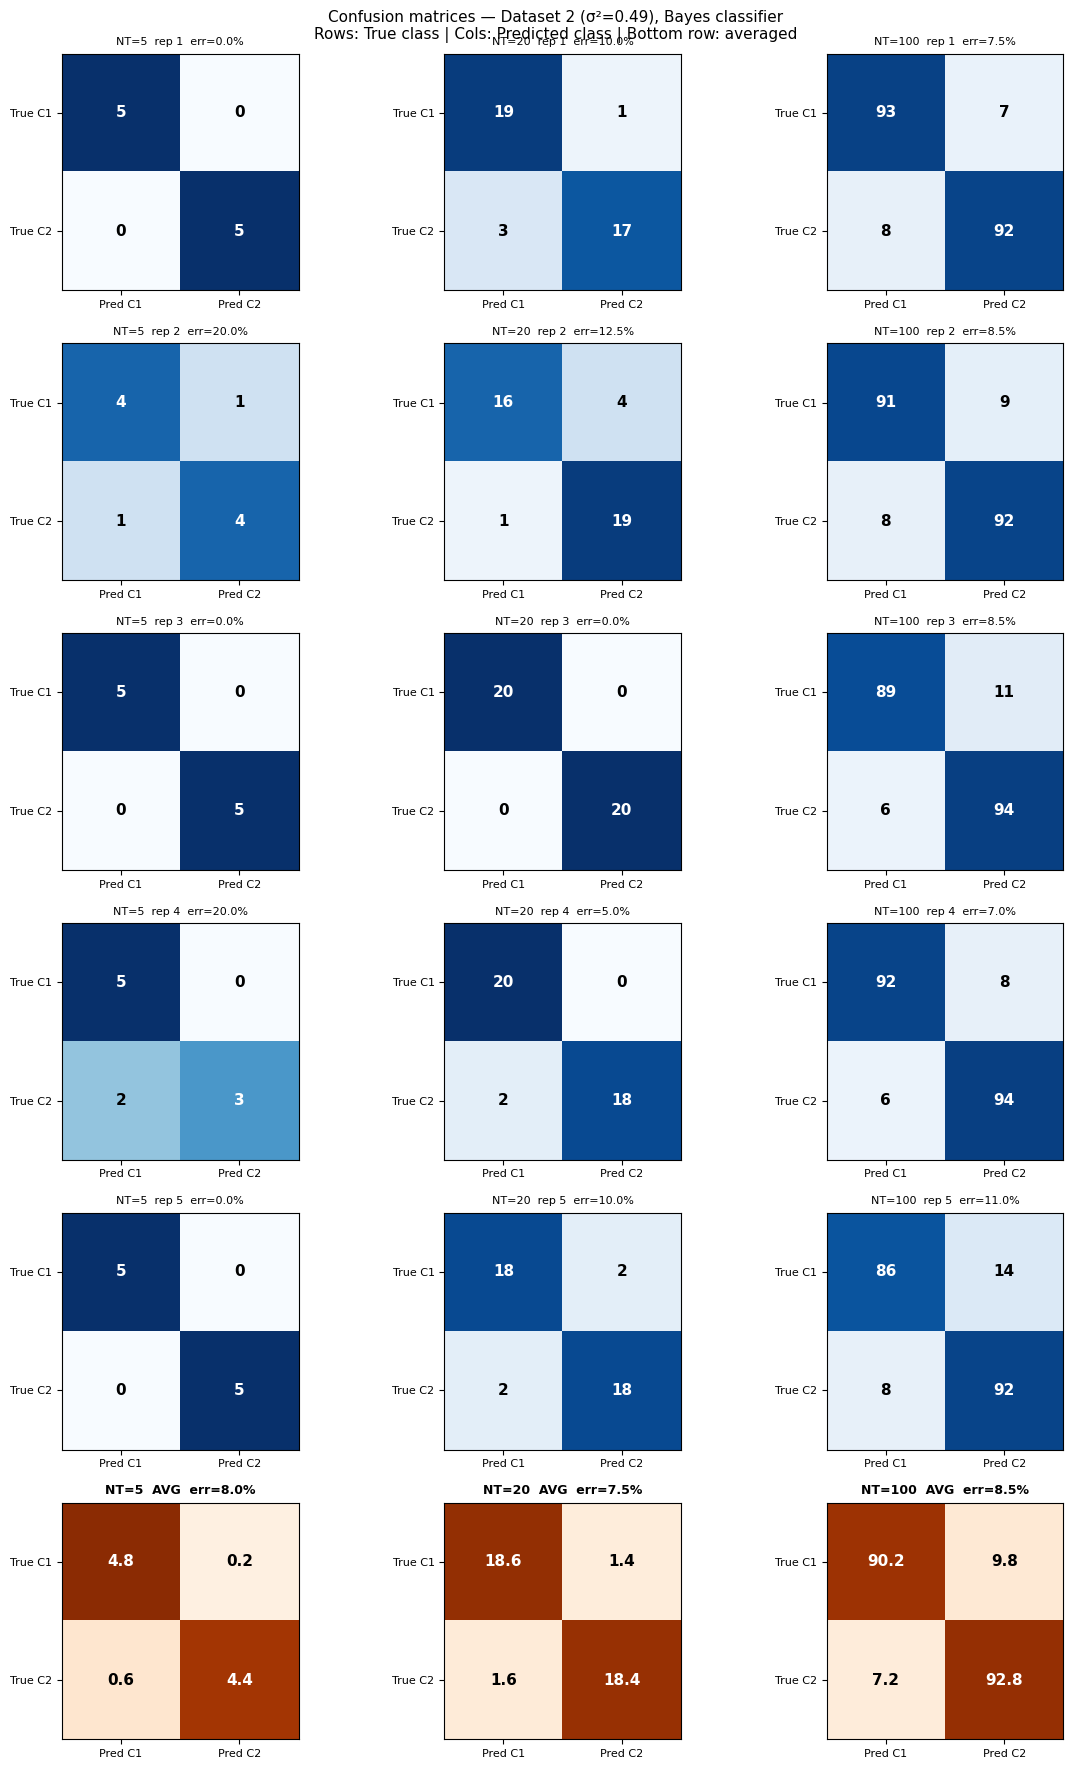

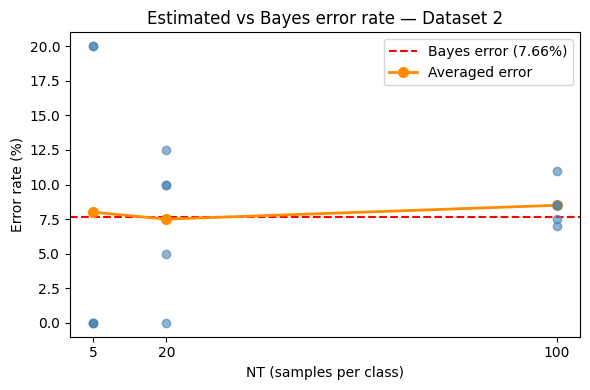

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(seed=0)

# ── Load dataset 2 (σ² = 0.49) and extract test split ────────────────────────
data = np.load("datasets/dataset_2_sigma2_049.npy")
# layout: rows 0-999 = class 1, rows 1000-1999 = class 2
# test = last 500 per class
test_c1 = data[500:1000, 0]   # 500 samples, label 0
test_c2 = data[1500:2000, 0]  # 500 samples, label 1

# True densities (σ² = 0.49 → σ = 0.7)
m1_true, m2_true, sigma_true = -1.0, 1.0, 0.7

def bayes_classify(x):
    """Classify using true class densities (equal priors → compare likelihoods)."""
    return (norm.pdf(x, m2_true, sigma_true) >= norm.pdf(x, m1_true, sigma_true)).astype(int)

def confusion_matrix_2x2(y_true, y_pred):
    """Return [[TN, FP], [FN, TP]] as a 2×2 numpy array."""
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def error_rate(cm):
    return (cm[0, 1] + cm[1, 0]) / cm.sum()

# ── Experiment setup ──────────────────────────────────────────────────────────
NT_values  = [5, 20, 100]
N_repeats  = 5

# Shuffle once so slices are non-overlapping across repeats
idx_c1 = rng.permutation(len(test_c1))
idx_c2 = rng.permutation(len(test_c2))

print(f"Dataset 2  (σ² = 0.49,  Bayes error = 7.66%)")
print("=" * 70)

all_results = {}   # NT -> list of (cm, err) per repeat

for NT in NT_values:
    needed = NT * N_repeats
    assert needed <= 500, f"Not enough test samples for NT={NT} × {N_repeats} repeats"

    cms  = []
    errs = []

    for rep in range(N_repeats):
        s, e = rep * NT, (rep + 1) * NT
        x_c1 = test_c1[idx_c1[s:e]]
        x_c2 = test_c2[idx_c2[s:e]]

        X      = np.concatenate([x_c1, x_c2])
        y_true = np.concatenate([np.zeros(NT, dtype=int), np.ones(NT, dtype=int)])
        y_pred = bayes_classify(X)

        cm  = confusion_matrix_2x2(y_true, y_pred)
        err = error_rate(cm)
        cms.append(cm)
        errs.append(err)

    all_results[NT] = (cms, errs)

    print(f"\n── NT = {NT} per class ({'%d' % (NT*2)} total) ──────────────────────────────")
    for rep, (cm, err) in enumerate(zip(cms, errs)):
        print(f"  Repeat {rep+1}:  CM = [[{cm[0,0]:3d} {cm[0,1]:3d}]   error = {err*100:5.1f}%")
        print(f"              [{cm[1,0]:3d} {cm[1,1]:3d}]]")

    avg_cm  = np.mean(cms, axis=0)
    avg_err = np.mean(errs)
    print(f"\n  Averaged CM (over {N_repeats} repeats):")
    print(f"    [[{avg_cm[0,0]:6.2f}  {avg_cm[0,1]:6.2f}]")
    print(f"     [{avg_cm[1,0]:6.2f}  {avg_cm[1,1]:6.2f}]]")
    print(f"  Averaged error rate : {avg_err*100:.2f}%")

print("\n" + "=" * 70)

# ── Visual: confusion matrices + avg error vs NT ──────────────────────────────
fig, axes = plt.subplots(N_repeats + 1, len(NT_values),
                         figsize=(4 * len(NT_values), 3 * (N_repeats + 1)))

for col, NT in enumerate(NT_values):
    cms, errs = all_results[NT]

    for row in range(N_repeats):
        ax  = axes[row, col]
        cm  = cms[row]
        im  = ax.imshow(cm, cmap="Blues", vmin=0, vmax=NT)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred C1", "Pred C2"], fontsize=8)
        ax.set_yticklabels(["True C1", "True C2"], fontsize=8)
        for r in range(2):
            for c in range(2):
                ax.text(c, r, str(cm[r, c]), ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color="white" if cm[r, c] > NT * 0.5 else "black")
        ax.set_title(f"NT={NT}  rep {row+1}  err={errs[row]*100:.1f}%", fontsize=8)

    # Bottom row: averaged CM
    ax      = axes[N_repeats, col]
    avg_cm  = np.mean(cms, axis=0)
    avg_err = np.mean(errs)
    im      = ax.imshow(avg_cm, cmap="Oranges", vmin=0, vmax=NT)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred C1", "Pred C2"], fontsize=8)
    ax.set_yticklabels(["True C1", "True C2"], fontsize=8)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{avg_cm[r,c]:.1f}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if avg_cm[r, c] > NT * 0.5 else "black")
    ax.set_title(f"NT={NT}  AVG  err={avg_err*100:.1f}%", fontsize=9, fontweight="bold")

fig.suptitle("Confusion matrices — Dataset 2 (σ²=0.49), Bayes classifier\n"
             "Rows: True class | Cols: Predicted class | Bottom row: averaged", fontsize=11)
plt.tight_layout()
plt.show()

# Summary plot: averaged error vs NT with individual dots
avg_errs = [np.mean(all_results[NT][1]) * 100 for NT in NT_values]
all_errs = [[e * 100 for e in all_results[NT][1]] for NT in NT_values]

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.axhline(7.66, color="red", linestyle="--", linewidth=1.5, label="Bayes error (7.66%)")
for i, NT in enumerate(NT_values):
    ax2.scatter([NT] * N_repeats, all_errs[i], color="steelblue", alpha=0.6, zorder=3)
ax2.plot(NT_values, avg_errs, "o-", color="darkorange", linewidth=2,
         markersize=7, label="Averaged error")
ax2.set_xlabel("NT (samples per class)")
ax2.set_ylabel("Error rate (%)")
ax2.set_title("Estimated vs Bayes error rate — Dataset 2")
ax2.legend()
ax2.set_xticks(NT_values)
plt.tight_layout()
plt.show()

d)

In [4]:
import numpy as np

print("Averaged error rate vs. pooled (single-test) error rate")
print("=" * 62)
print(f"{'NT':>6}  {'Avg of 5 rates':>16}  {'Pooled rate':>13}  {'Same?':>7}")
print("-" * 62)

for NT in NT_values:
    cms, errs = all_results[NT]

    # Method 1: average of the 5 individual error rates (from part c)
    avg_err = np.mean(errs)

    # Method 2: pool all 5 x 2NT samples into one single test
    total_errors  = sum(cm[0, 1] + cm[1, 0] for cm in cms)
    total_samples = N_repeats * 2 * NT
    pooled_err    = total_errors / total_samples

    same = np.isclose(avg_err, pooled_err)
    print(f"{NT:>6}  {avg_err*100:>14.4f}%  {pooled_err*100:>11.4f}%  {'YES' if same else 'NO':>7}")

print("=" * 62)
print()
print("Because every repeat uses the same NT, the two quantities are")
print("algebraically identical:")
print()
print("  avg_err = (1/5) * sum_i( errors_i / (2*NT) )")
print("          = sum_i(errors_i) / (5 * 2 * NT)")
print("          = pooled_err")
print()
print("They would differ only if the repeats had DIFFERENT sizes,")
print("since averaging rates weights each repeat equally regardless of")
print("how many samples it contributed.")

Averaged error rate vs. pooled (single-test) error rate
    NT    Avg of 5 rates    Pooled rate    Same?
--------------------------------------------------------------
     5          8.0000%       8.0000%      YES
    20          7.5000%       7.5000%      YES
   100          8.5000%       8.5000%      YES

Because every repeat uses the same NT, the two quantities are
algebraically identical:

  avg_err = (1/5) * sum_i( errors_i / (2*NT) )
          = sum_i(errors_i) / (5 * 2 * NT)
          = pooled_err

They would differ only if the repeats had DIFFERENT sizes,
since averaging rates weights each repeat equally regardless of
how many samples it contributed.


e) Datasets 1 & 3 — same analysis


Dataset  σ²=0.25  σ=0.5  Bayes error=2.28%
    NT     Avg err    Pooled err    Same?
------------------------------------------
     5       2.00%         2.00%      YES
       Individual repeats:
         rep1: CM=[[  5,  0],[  0,  5]]  err=0.0%
         rep2: CM=[[  5,  0],[  0,  5]]  err=0.0%
         rep3: CM=[[  5,  0],[  1,  4]]  err=10.0%
         rep4: CM=[[  5,  0],[  0,  5]]  err=0.0%
         rep5: CM=[[  5,  0],[  0,  5]]  err=0.0%
       Avg CM: [[5.0,0.0],[0.2,4.8]]
    20       1.00%         1.00%      YES
       Individual repeats:
         rep1: CM=[[ 20,  0],[  1, 19]]  err=2.5%
         rep2: CM=[[ 20,  0],[  0, 20]]  err=0.0%
         rep3: CM=[[ 20,  0],[  0, 20]]  err=0.0%
         rep4: CM=[[ 19,  1],[  0, 20]]  err=2.5%
         rep5: CM=[[ 20,  0],[  0, 20]]  err=0.0%
       Avg CM: [[19.8,0.2],[0.2,19.8]]
   100       2.60%         2.60%      YES
       Individual repeats:
         rep1: CM=[[ 99,  1],[  1, 99]]  err=1.0%
         rep2: CM=[[ 97,  3],[  5, 95

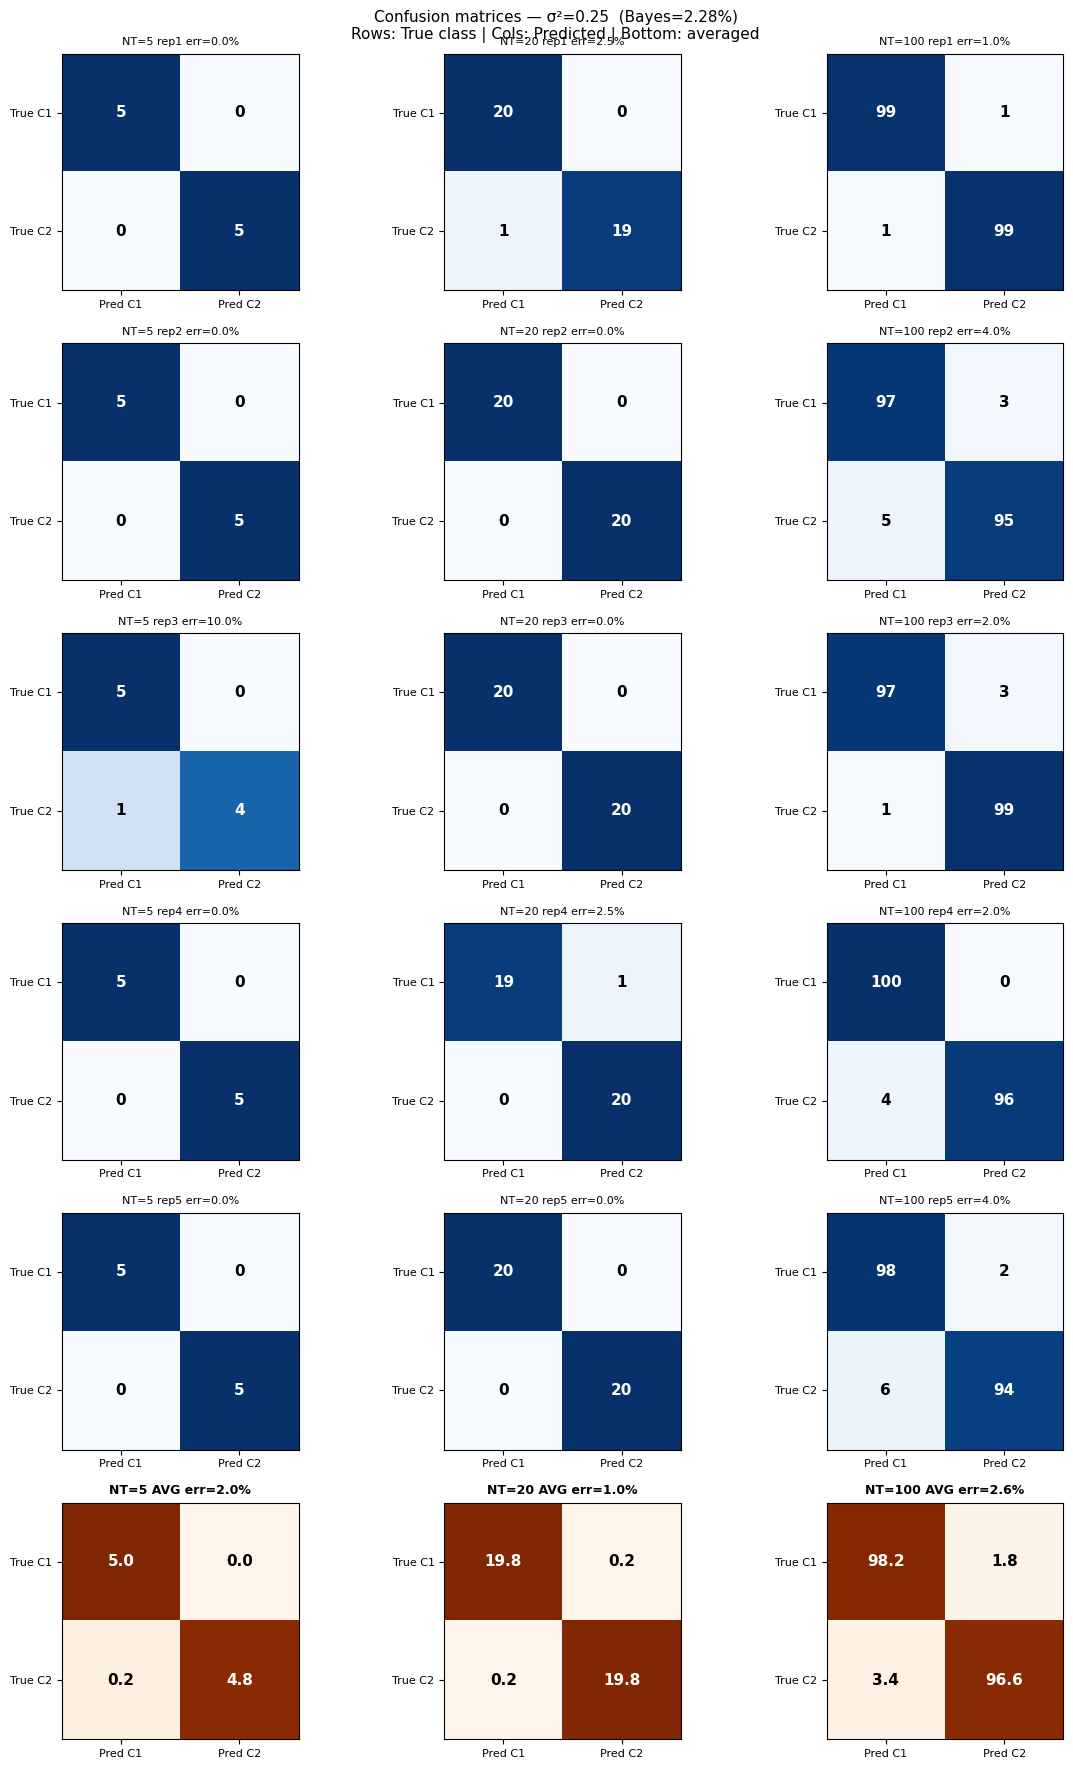

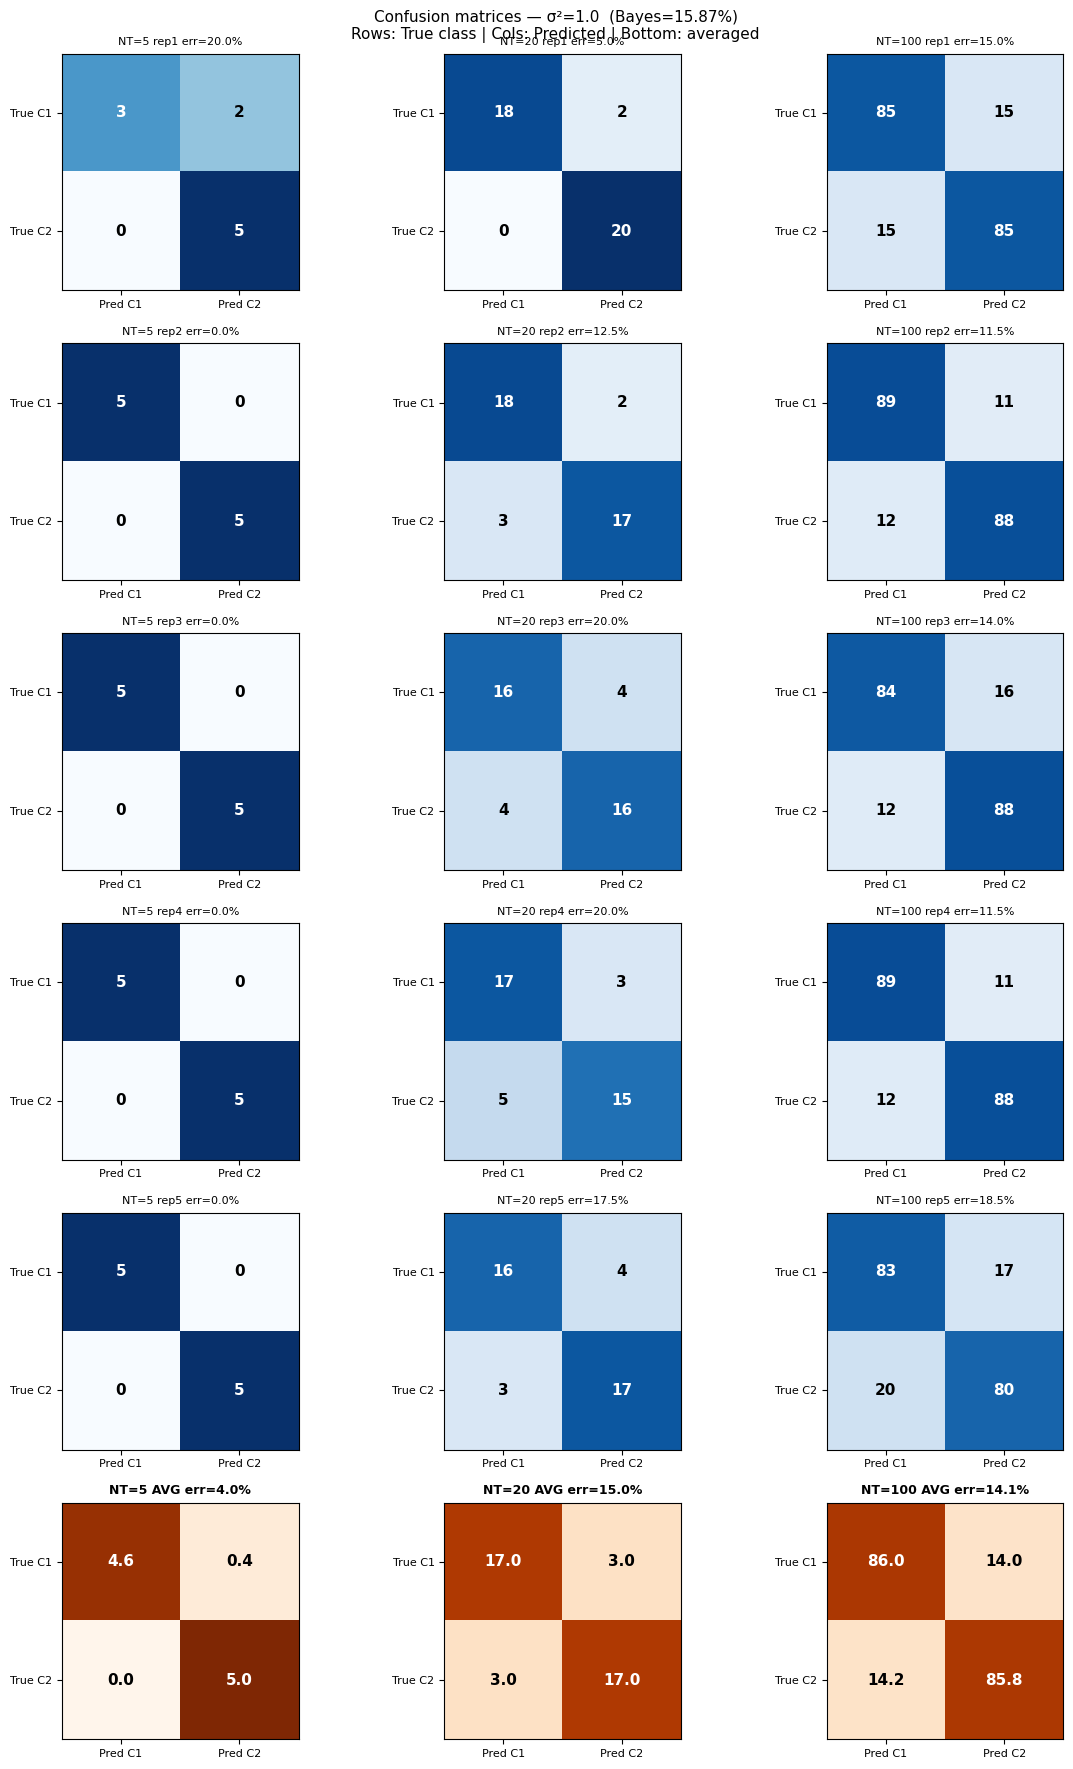

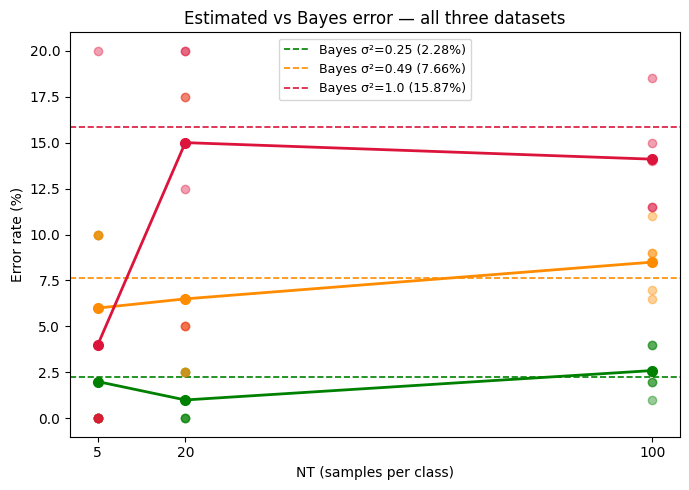

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import erfc

rng2 = np.random.default_rng(seed=1)

# ── All three datasets ────────────────────────────────────────────────────────
datasets = [
    ("datasets/dataset_1_sigma2_025.npy", 0.25, 0.50),
    ("datasets/dataset_2_sigma2_049.npy", 0.49, 0.70),
    ("datasets/dataset_3_sigma2_10.npy",  1.00, 1.00),
]

NT_values  = [5, 20, 100]
N_repeats  = 5
m1_t, m2_t = -1.0, 1.0

def bayes_clf(x, sigma):
    return (norm.pdf(x, m2_t, sigma) >= norm.pdf(x, m1_t, sigma)).astype(int)

def cm2x2(y_true, y_pred):
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def error_rate(cm):
    return (cm[0,1] + cm[1,0]) / cm.sum()

# ── Loop over datasets ────────────────────────────────────────────────────────
all_ds_results = {}   # ds_idx -> {NT: (cms, errs)}

for ds_path, sigma2, sigma in datasets:
    data    = np.load(ds_path)
    tc1     = data[500:1000, 0]
    tc2     = data[1500:2000, 0]
    bayes_pe = 0.5 * erfc(abs(m2_t - m1_t) / (2 * sigma * np.sqrt(2)))

    idx1 = rng2.permutation(500)
    idx2 = rng2.permutation(500)

    ds_results = {}
    print(f"\n{'='*70}")
    print(f"Dataset  σ²={sigma2}  σ={sigma}  Bayes error={bayes_pe*100:.2f}%")
    print(f"{'='*70}")
    print(f"{'NT':>6}  {'Avg err':>10}  {'Pooled err':>12}  {'Same?':>7}")
    print(f"{'-'*42}")

    for NT in NT_values:
        cms, errs = [], []
        for rep in range(N_repeats):
            s, e   = rep * NT, (rep+1) * NT
            X      = np.concatenate([tc1[idx1[s:e]], tc2[idx2[s:e]]])
            y_true = np.concatenate([np.zeros(NT, int), np.ones(NT, int)])
            y_pred = bayes_clf(X, sigma)
            cm     = cm2x2(y_true, y_pred)
            cms.append(cm); errs.append(error_rate(cm))

        ds_results[NT] = (cms, errs)
        avg_err    = np.mean(errs)
        pooled_err = sum(cm[0,1]+cm[1,0] for cm in cms) / (N_repeats*2*NT)
        print(f"{NT:>6}  {avg_err*100:>9.2f}%  {pooled_err*100:>11.2f}%  {'YES' if np.isclose(avg_err,pooled_err) else 'NO':>7}")

        print(f"       Individual repeats:")
        for rep, (cm, err) in enumerate(zip(cms, errs)):
            print(f"         rep{rep+1}: CM=[[{cm[0,0]:3d},{cm[0,1]:3d}],[{cm[1,0]:3d},{cm[1,1]:3d}]]  err={err*100:.1f}%")
        avg_cm = np.mean(cms, axis=0)
        print(f"       Avg CM: [[{avg_cm[0,0]:.1f},{avg_cm[0,1]:.1f}],[{avg_cm[1,0]:.1f},{avg_cm[1,1]:.1f}]]")

    all_ds_results[sigma2] = (ds_results, sigma, bayes_pe)

# ── Plot: confusion matrices for datasets 1 & 3 ───────────────────────────────
for sigma2 in [0.25, 1.00]:
    ds_results, sigma, bayes_pe = all_ds_results[sigma2]

    fig, axes = plt.subplots(N_repeats + 1, len(NT_values),
                             figsize=(4*len(NT_values), 3*(N_repeats+1)))

    for col, NT in enumerate(NT_values):
        cms, errs = ds_results[NT]
        for row in range(N_repeats):
            ax = axes[row, col]; cm = cms[row]
            ax.imshow(cm, cmap="Blues", vmin=0, vmax=NT)
            ax.set_xticks([0,1]); ax.set_yticks([0,1])
            ax.set_xticklabels(["Pred C1","Pred C2"], fontsize=8)
            ax.set_yticklabels(["True C1","True C2"], fontsize=8)
            for r in range(2):
                for c in range(2):
                    ax.text(c, r, str(cm[r,c]), ha="center", va="center",
                            fontsize=11, fontweight="bold",
                            color="white" if cm[r,c] > NT*0.5 else "black")
            ax.set_title(f"NT={NT} rep{row+1} err={errs[row]*100:.1f}%", fontsize=8)

        avg_cm  = np.mean(cms, axis=0)
        avg_err = np.mean(errs)
        ax = axes[N_repeats, col]
        ax.imshow(avg_cm, cmap="Oranges", vmin=0, vmax=NT)
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(["Pred C1","Pred C2"], fontsize=8)
        ax.set_yticklabels(["True C1","True C2"], fontsize=8)
        for r in range(2):
            for c in range(2):
                ax.text(c, r, f"{avg_cm[r,c]:.1f}", ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color="white" if avg_cm[r,c] > NT*0.5 else "black")
        ax.set_title(f"NT={NT} AVG err={avg_err*100:.1f}%", fontsize=9, fontweight="bold")

    fig.suptitle(f"Confusion matrices — σ²={sigma2}  (Bayes={bayes_pe*100:.2f}%)\n"
                 "Rows: True class | Cols: Predicted | Bottom: averaged", fontsize=11)
    plt.tight_layout()
    plt.show()

# ── Summary: averaged error vs NT for all three datasets ──────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 5))
colors = {0.25: "green", 0.49: "darkorange", 1.00: "crimson"}

for sigma2 in [0.25, 0.49, 1.00]:
    ds_results, sigma, bayes_pe = all_ds_results[sigma2]
    avgs  = [np.mean(ds_results[NT][1])*100 for NT in NT_values]
    indiv = [[e*100 for e in ds_results[NT][1]] for NT in NT_values]
    c     = colors[sigma2]
    ax3.axhline(bayes_pe*100, color=c, linestyle="--", linewidth=1.2,
                label=f"Bayes σ²={sigma2} ({bayes_pe*100:.2f}%)")
    for i, NT in enumerate(NT_values):
        ax3.scatter([NT]*N_repeats, indiv[i], color=c, alpha=0.4, zorder=3)
    ax3.plot(NT_values, avgs, "o-", color=c, linewidth=2, markersize=7)

ax3.set_xlabel("NT (samples per class)")
ax3.set_ylabel("Error rate (%)")
ax3.set_title("Estimated vs Bayes error — all three datasets")
ax3.legend(fontsize=9)
ax3.set_xticks(NT_values)
plt.tight_layout()
plt.show()